# Clustering với DBSCAN

Nguồn: https://www.digitalvidya.com/blog/the-top-5-clustering-algorithms-data-scientists-should-know/
![image.png](https://imgur.com/9D6aAF2.gif)

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định
(Cùng dữ liệu giả với `03_Demo-kMeans.ipynb`)

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

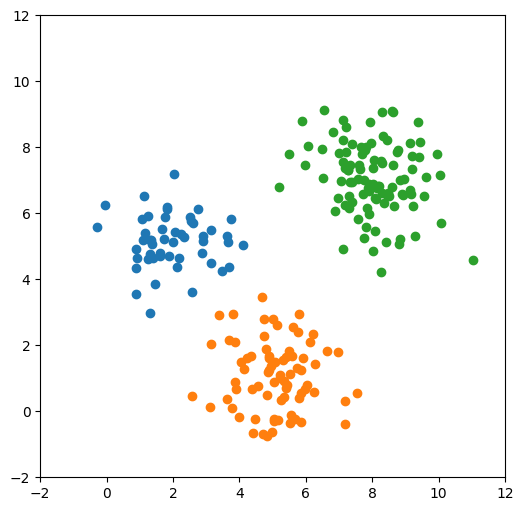

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập

In [4]:
dat1 = np.stack([x1,y1]).T
dat1.shape

(50, 2)

In [5]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

In [6]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [7]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

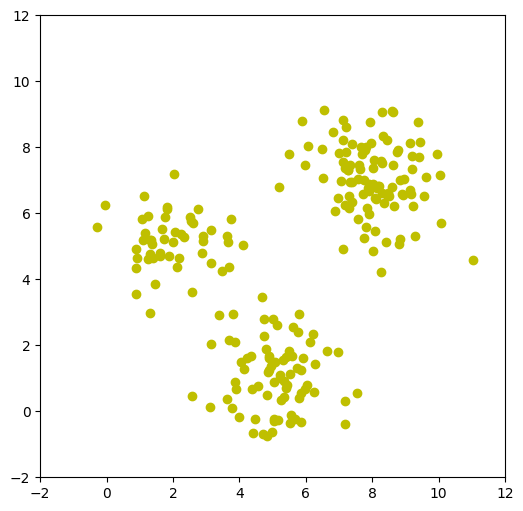

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm bằng DBSCAN

**=== Import lớp DBSCAN từ thư viện sklearn ===**

In [9]:
from sklearn.cluster import DBSCAN

### 2.1. Khởi tạo model và fit vào dữ liệu

In [10]:
# Giả sử chọn epsilon = 1, minPoints = 5
model = DBSCAN(eps=1, min_samples=5)

**=== Thực hiện fit vào dữ liệu ===**

In [11]:
model.fit(dat)

DBSCAN(eps=1)

### 2.2. Kiểm tra kết quả các cluster tìm được

**=== Lấy ra nhãn các clusters ===**

In [12]:
cluster = model.labels_

In [13]:
cluster

array([ 0,  0,  2,  1,  1,  2,  0,  1,  1,  1,  1,  0,  0,  2,  2,  0,  2,
        0,  1,  2,  1,  0,  0,  2,  0,  0,  1,  1,  1,  0,  0,  2,  2,  1,
        1,  1,  0,  2,  2,  2,  2,  2,  0, -1,  0, -1,  1,  2,  0,  2,  0,
        1,  2,  0,  1,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  2,  1,
        2,  0,  0,  0, -1,  2,  2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,
        0,  0, -1, -1,  0,  0,  2,  0,  0,  0,  0,  1,  1,  1,  0,  0,  2,
        0,  0,  0,  1,  1, -1,  0, -1,  1,  0,  1,  0,  0,  0,  1,  1,  2,
        1,  0,  0,  0,  0,  0,  0,  0,  2,  1,  1,  2,  2,  1,  0,  0,  0,
        2,  1,  0,  0,  1,  1,  2,  0,  0,  1,  0,  1,  0,  1,  1,  1,  0,
        1,  2,  1,  1,  0,  1,  2,  2,  0,  1,  0,  2,  2,  0,  1,  1,  1,
        1,  1,  1,  0,  0,  0,  0,  0,  0,  2,  2,  0,  0,  1,  1,  1,  0,
        1,  0,  2,  1,  1,  1,  0,  1,  2,  2,  1,  1,  1,  0,  2,  1,  0,
        0,  2,  1,  1,  0,  2,  1,  2,  0,  1,  0,  0,  2,  1,  1,  0,  2,
        2,  1,  2,  0])

**=== Đếm xem mỗi cluster có bao nhiêu điểm ===**

In [14]:
np.unique(cluster, return_counts=True)

(array([-1,  0,  1,  2]), array([ 7, 98, 73, 47]))

**=== Hiển thị lên biểu đồ ===**

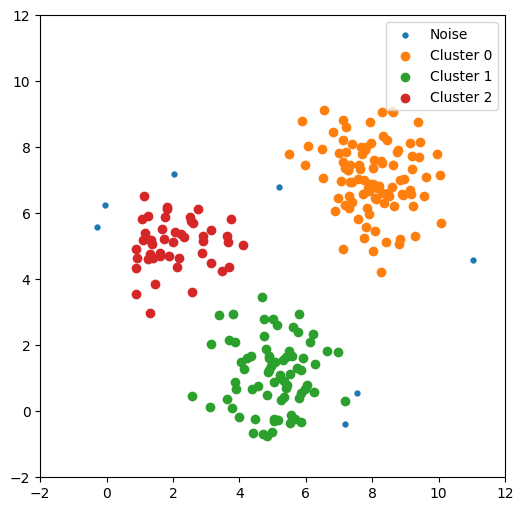

In [15]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

for label in np.unique(cluster):
    samples = dat[cluster == label]
    
    if label == -1:
        plt.scatter(
            samples[:,0],
            samples[:,1],
            marker='.',
            s=50,
            label='Noise'
        )
    else:
        plt.scatter(
            samples[:,0],
            samples[:,1],
            label=f'Cluster {label}'
        )

plt.legend()

plt.show()

### 2.3. Tính hiệu suất phân cụm

**=== Thử tính với hàm built-in của Sklearn ===**

In [16]:
from sklearn.metrics import silhouette_score

In [17]:
silhouette_score(dat, cluster)

np.float64(0.639460128792222)

**=== Tính lại với các cụm không chứa điểm noise ===**

In [18]:
import pandas as pd

In [19]:
# Bỏ đi các samples bị xác định là noise
mask = cluster != -1

dat2 = dat[mask]
cluster2 = cluster[mask]

In [20]:
print(dat2.shape)
print(cluster2)

(218, 2)
[0 0 2 1 1 2 0 1 1 1 1 0 0 2 2 0 2 0 1 2 1 0 0 2 0 0 1 1 1 0 0 2 2 1 1 1 0
 2 2 2 2 2 0 0 1 2 0 2 0 1 2 0 1 0 0 1 0 0 0 1 0 0 0 0 2 1 2 0 0 0 2 2 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 2 0 0 0 0 1 1 1 0 0 2 0 0 0 1 1 0 1 0 1 0 0 0 1 1
 2 1 0 0 0 0 0 0 0 2 1 1 2 2 1 0 0 0 2 1 0 0 1 1 2 0 0 1 0 1 0 1 1 1 0 1 2
 1 1 0 1 2 2 0 1 0 2 2 0 1 1 1 1 1 1 0 0 0 0 0 0 2 2 0 0 1 1 1 0 1 0 2 1 1
 1 0 1 2 2 1 1 1 0 2 1 0 0 2 1 1 0 2 1 2 0 1 0 0 2 1 1 0 2 2 1 2 0]


In [21]:
# Tạo một list rỗng để chứa hệ số Silhouette của mỗi sample
s_list = []

for i, sample in enumerate(dat2):
    label = cluster2[i]
    
    # Lấy ra các samples khác và nhãn khác
    other_samples = np.delete(dat2, i, axis=0)
    other_labels = np.delete(cluster2, i)
    
    # Tính khoảng cách từ sample đến tất cả các other_samples
    distances = np.sqrt(
        np.sum((other_samples - sample)**2, axis=1)
    )
    
    # Tạo dataframe với 2 cột 'distance' và 'cluster' để dùng groupby tính mean()
    df = pd.DataFrame({
        'distance': distances,
        'cluster': other_labels
    })
    
    
    # Lấy ra giá trị p, q tương ứng
    # p: khoảng cách trung bình đến các điểm cùng cluster
    p = df[df['cluster'] == label]['distance'].mean()
    
    # q: khoảng cách trung bình nhỏ nhất đến một cluster khác
    q = df[df['cluster'] != label].groupby(
        'cluster'
    )['distance'].mean().min()
    
    # Tính ra hệ số Silhouette cho sample
    s = (q - p) / max(p, q)
    
    s_list.append(s)
    

In [22]:
# Tính trung bình hệ số Silhouette của tất cả các samples
silhouette_manual = np.mean(s_list)

print(silhouette_manual)

0.6854228250080899


**==> Thử thực hiện lại mà không bỏ giá trị noise?**

In [23]:
silhouette_with_noise = silhouette_score(dat, cluster)

print("Silhouette khi giữ noise:", silhouette_with_noise)

Silhouette khi giữ noise: 0.639460128792222


In [24]:
print("Có noise   :", silhouette_with_noise)
print("Không noise:", silhouette_score(dat2, cluster2))

Có noise   : 0.639460128792222
Không noise: 0.68542282500809
